# Porter Deliveries — BDM Capstone Final Analysis
**Student:** 22f3000963 | **IIT Madras**

Reproduces every figure and finding from the final submission report exactly.

## 0. Imports & Setup

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})
print("Libraries successfully loaded.")

Libraries successfully loaded.


## 1. Data Loading — Upload `porter.csv`
Run the cell below and use the **Upload** button to select your `porter.csv` file.
The cleaned dataset will be saved as `cleaned_porter.csv` in the same folder and can be downloaded afterwards.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML
import io, os

# Output widget captures all feedback and shows it inline below the button
out = widgets.Output()

upload = widgets.FileUpload(accept='.csv', multiple=False, description='📂 Upload porter.csv')

status = widgets.HTML(value="<i style='color:grey'>⏳ Waiting for file upload...</i>")

def on_upload(change):
    out.clear_output()
    with out:
        if not upload.value:
            return
        try:
            filename = list(upload.value.keys())[0]
            content  = list(upload.value.values())[0]['content']
            global df
            df = pd.read_csv(io.BytesIO(content))
            status.value = f"<b style='color:green; font-size:14px'>✅ '{filename}' uploaded successfully! &nbsp;&nbsp; Shape: {df.shape[0]:,} rows × {df.shape[1]} columns</b>"
            print("── Preview (first 3 rows) ──")
            display(df.head(3))
            print(f"── Missing Values ──")
            print(df.isna().sum()[df.isna().sum() > 0].to_string() or "None")
        except Exception as e:
            status.value = f"<b style='color:red'>❌ Upload failed: {e}</b>"

upload.observe(on_upload, names='value')

display(widgets.VBox([upload, status, out]))

## 2. Data Understanding

In [15]:
print(f"Dataset Shape: {df.shape}")
print("\n--- Data Sample ---")
display(df.sample(3, random_state=1))
print("\n--- Dataset Info ---")
df.info()
print("\n--- Missing Values ---")
print(df.isna().sum())
print("\n--- Duplicated Rows ---")
print(df.duplicated().sum())

Dataset Shape: (197428, 14)

--- Data Sample ---


,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
54056,1.0,2015-02-13 22:02:02,2015-02-13 23:12:41,b4fda13184e80a58eb1388a0847dfbd5,breakfast,5.0,3,3135,2,895,995,9.0,9.0,20.0
172570,6.0,2015-01-27 03:47:08,2015-01-27 04:27:06,d9a8c56824cfbe66f28f85edbbe83e09,breakfast,5.0,2,3200,1,1225,1225,NaN,NaN,NaN
44517,2.0,2015-01-27 01:27:59,2015-01-27 02:25:25,28f0b864598a1291557bed248a998d4e,pizza,3.0,2,2550,2,275,2275,55.0,85.0,67.0



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   market_id                 196441 non-null  float64
 1   created_at                197428 non-null  object 
 2   actual_delivery_time      197421 non-null  object 
 3   store_id                  197428 non-null  object 
 4   store_primary_category    192668 non-null  object 
 5   order_protocol            196433 non-null  float64
 6   total_items               197428 non-null  int64  
 7   subtotal                  197428 non-null  int64  
 8   num_distinct_items        197428 non-null  int64  
 9   min_item_price            197428 non-null  int64  
 10  max_item_price            197428 non-null  int64  
 11  total_onshift_partners    181166 non-null  float64
 12  total_busy_partners       181166 non-null  float64
 13  total_outstanding_orde

## 3. Data Cleaning & Feature Engineering
**Mathematical Abstraction (from report):**
> `delivery_duration_mins = (actual_delivery_time − created_at) / 60.0`

Missing values in `total_onshift_partners` are **median-imputed** to prevent artificial skewing of the predictive ETA model.

In [16]:
def clean_porter_data(data):
    data['created_at'] = pd.to_datetime(data['created_at'])
    data['actual_delivery_time'] = pd.to_datetime(data['actual_delivery_time'])

    # Target Variable Extraction
    data['delivery_duration_mins'] = (
        data['actual_delivery_time'] - data['created_at']
    ).dt.total_seconds() / 60.0

    # Drop corrupted rows
    data = data.dropna(subset=['created_at', 'actual_delivery_time'])
    data = data[(data['delivery_duration_mins'] > 0) & (data['delivery_duration_mins'] < 300)]

    # Mathematical Imputation using Medians
    median_partners = data['total_onshift_partners'].median()
    median_orders   = data['total_outstanding_orders'].median()
    data['total_onshift_partners']    = data['total_onshift_partners'].fillna(median_partners)
    data['total_outstanding_orders']  = data['total_outstanding_orders'].fillna(median_orders)

    # Remove invalid negative driver counts
    data = data[data['total_onshift_partners'] >= 0]

    # Temporal Feature Engineering
    data['Hour']      = data['created_at'].dt.hour
    data['DayOfWeek'] = data['created_at'].dt.day_name()
    data['supply_deficit_ratio'] = data['total_outstanding_orders'] / (data['total_onshift_partners'] + 1)

    return data

df_cleaned = clean_porter_data(df.copy())
print("Data Cleaning Completed. Remaining Valid Records:", len(df_cleaned))

Data Cleaning Completed. Remaining Valid Records: 197365


In [ ]:
# Save cleaned dataset to cleaned_porter.csv in the current directory
save_path = os.path.join(os.getcwd(), 'cleaned_porter.csv')
df_cleaned.to_csv(save_path, index=False)
print(f"✅ Cleaned dataset saved → {save_path}")
print(f"   Records: {len(df_cleaned):,}  |  Columns: {df_cleaned.shape[1]}")

### ⬇️ Download Cleaned Dataset
Run the cell below to download `cleaned_porter.csv` to your machine.

In [ ]:
# ── Download cleaned_porter.csv directly from the notebook ──
from IPython.display import Javascript
import base64

with open('cleaned_porter.csv', 'rb') as f:
    b64 = base64.b64encode(f.read()).decode()

js = f'''
var a = document.createElement('a');
a.href = "data:text/csv;base64,{b64}";
a.download = "cleaned_porter.csv";
document.body.appendChild(a);
a.click();
document.body.removeChild(a);
'''
display(Javascript(js))
print("⬇️  Download started for cleaned_porter.csv")

## 4. Descriptive Statistics (Table 2 from Report)
Key anomaly: avg pending orders **(56.65)** exceeds avg active drivers **(44.17)** — foundational supply shortage. Max deficit: 285 orders vs 171 drivers.

In [17]:
stats_cols = ['total_items', 'subtotal', 'total_onshift_partners',
              'total_outstanding_orders', 'delivery_duration_mins']
labels     = ['Total Items', 'Subtotal (INR)', 'Active Drivers', 'Pending Orders', 'Delivery ETA (mins)']

desc_stats = df_cleaned[stats_cols].describe().T
desc_stats['range'] = desc_stats['max'] - desc_stats['min']
result = desc_stats[['mean', '50%', 'std', 'min', 'max', 'range']].round(2)
result.index = labels
result.columns = ['Mean', 'Median', 'Std Dev', 'Min', 'Max', 'Range']
display(result)

,Mean,Median,Std Dev,Min,Max,Range
Total Items,3.20,3.00,2.67,1.00,411.0,410.00
Subtotal (INR),2682.39,2200.00,1823.19,0.00,27100.0,27100.00
Active Drivers,44.17,37.00,33.14,0.00,171.0,171.00
Pending Orders,56.65,41.00,50.66,-6.00,285.0,291.00
Delivery ETA (mins),47.62,44.33,18.47,1.68,297.7,296.02


### Figure 1 — ETA Variance KDE Distribution Histogram

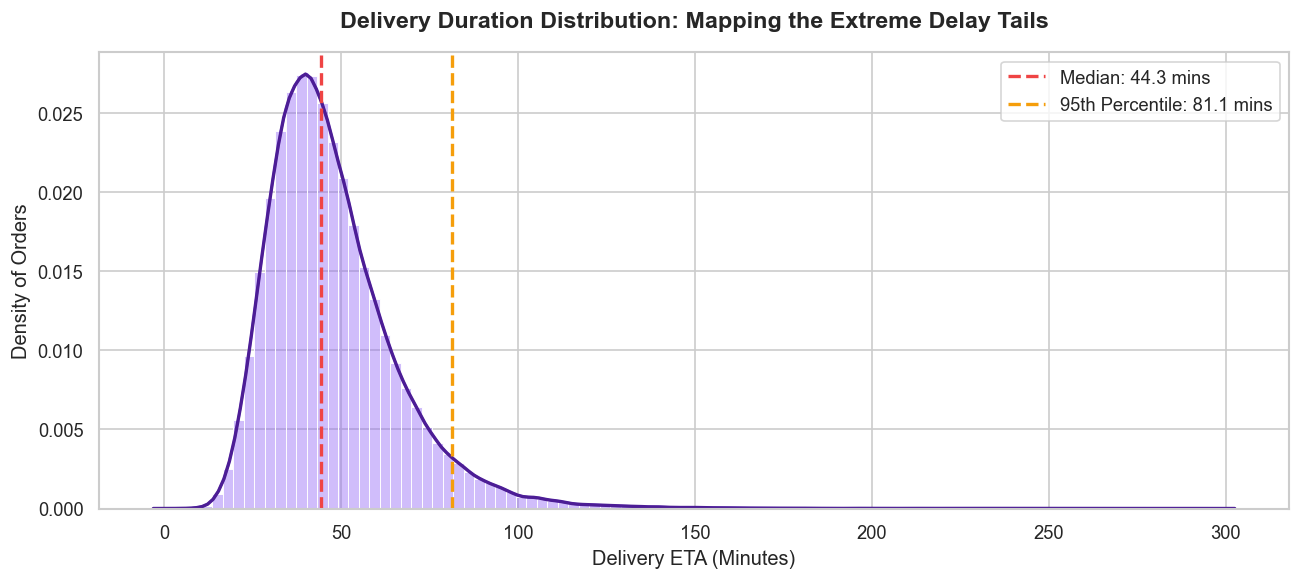

In [18]:
plt.figure(figsize=(11, 5))
sns.histplot(df_cleaned['delivery_duration_mins'], bins=100, kde=True,
             color='#8b5cf6', stat='density', alpha=0.4)
sns.kdeplot(df_cleaned['delivery_duration_mins'], color='#4c1d95', linewidth=2)
plt.title('Delivery Duration Distribution: Mapping the Extreme Delay Tails',
          pad=15, fontsize=14, fontweight='bold')
plt.xlabel('Delivery ETA (Minutes)', fontsize=12)
plt.ylabel('Density of Orders', fontsize=12)
plt.axvline(df_cleaned['delivery_duration_mins'].median(), color='#ef4444',
            linestyle='dashed', linewidth=2,
            label=f"Median: {df_cleaned['delivery_duration_mins'].median():.1f} mins")
plt.axvline(df_cleaned['delivery_duration_mins'].quantile(0.95), color='#f59e0b',
            linestyle='dashed', linewidth=2,
            label=f"95th Percentile: {df_cleaned['delivery_duration_mins'].quantile(0.95):.1f} mins")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Correlation Analysis (Section 5.1)
**Pearson Correlation** proves supply scales with demand but with an inherent lag — the primary trigger for delays.
> Key finding: r = **0.94** between `total_outstanding_orders` & `total_onshift_partners`

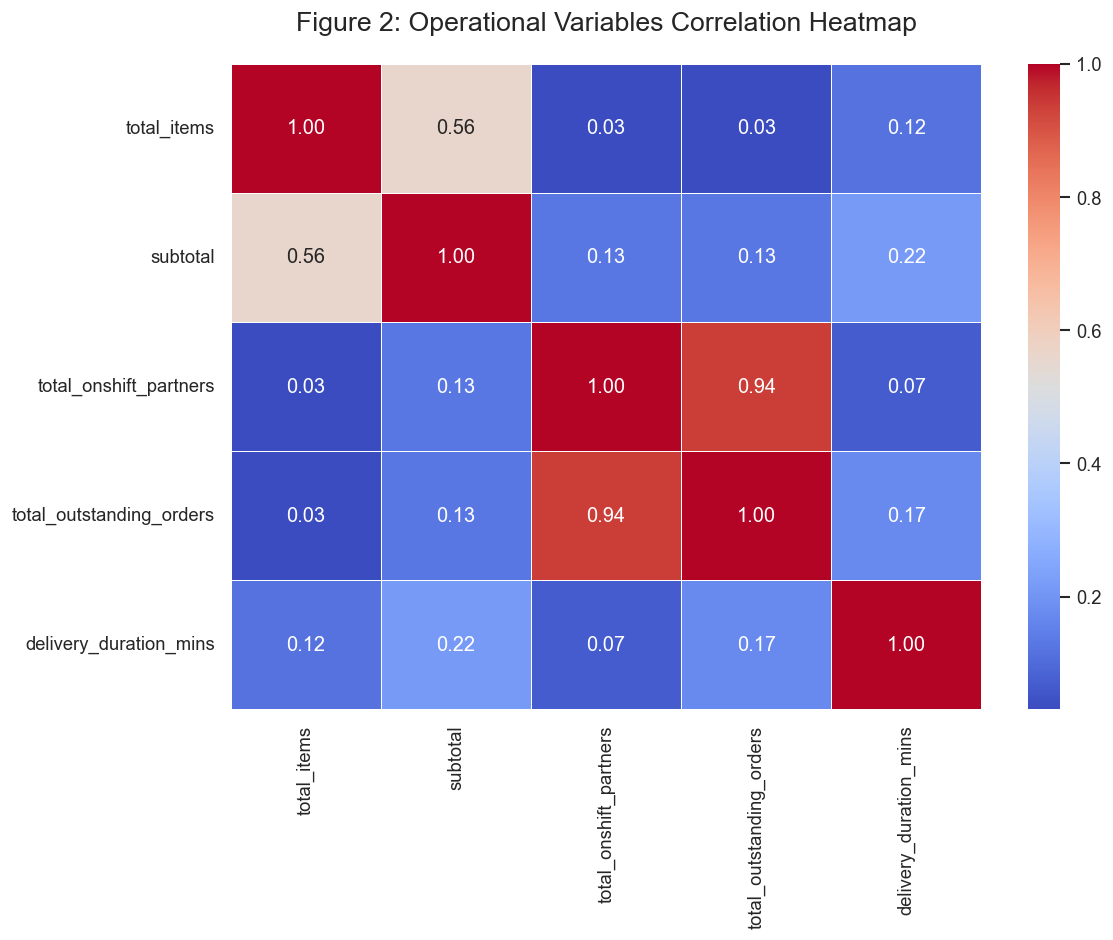

Supply-Demand Pearson r: 0.94


In [19]:
stats_cols = ['total_items', 'subtotal', 'total_onshift_partners',
              'total_outstanding_orders', 'delivery_duration_mins']

# Figure 2: Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df_cleaned[stats_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Figure 2: Operational Variables Correlation Heatmap', pad=20, fontsize=16)
plt.tight_layout()
plt.show()

print(f"Supply-Demand Pearson r: {corr_matrix.loc['total_outstanding_orders','total_onshift_partners']:.2f}")

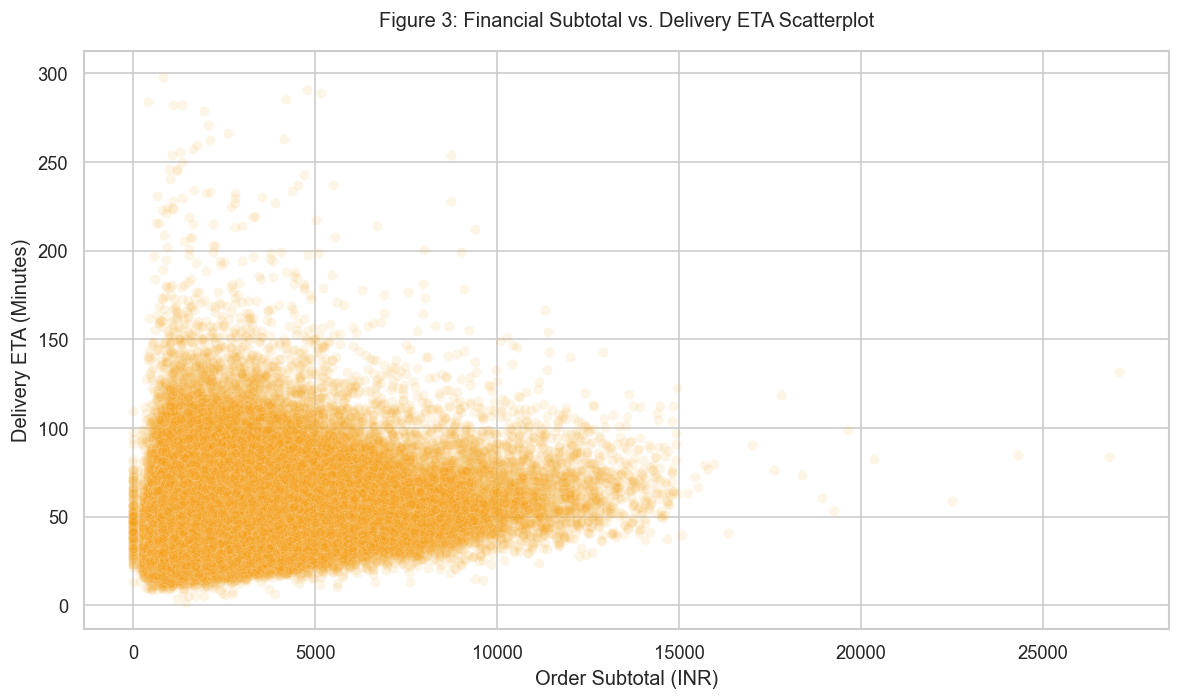

In [20]:
# Figure 3: Financial Subtotal vs Delivery ETA Scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='subtotal', y='delivery_duration_mins',
                data=df_cleaned, alpha=0.1, color='#f59e0b')
plt.title('Figure 3: Financial Subtotal vs. Delivery ETA Scatterplot', pad=15)
plt.xlabel('Order Subtotal (INR)')
plt.ylabel('Delivery ETA (Minutes)')
plt.tight_layout()
plt.show()

## 6. Temporal Demand Analysis (Section 5.2)
**Finding:** Network experiences massive demand surges peaking between **01:00 AM – 03:00 AM**.
Weekends show distinctly elevated logistical stress vs stable midweek operations.

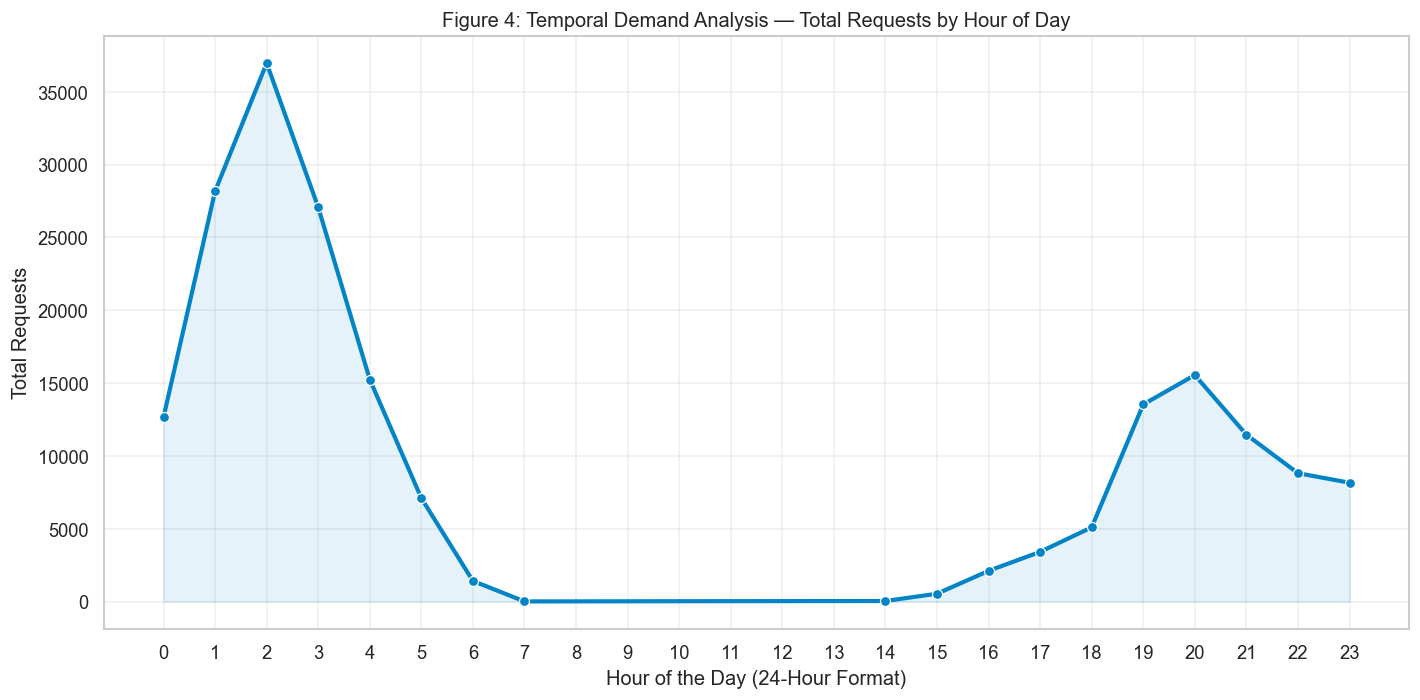

Peak demand hour: 2:00


In [21]:
# Figure 4: Temporal Demand Request Volume by Hour
plt.figure(figsize=(12, 6))
hourly_demand = df_cleaned.groupby('Hour').size().reset_index(name='Total Demands')
sns.lineplot(x='Hour', y='Total Demands', data=hourly_demand,
             marker='o', linewidth=2.5, color='#0284c7')
plt.title('Figure 4: Temporal Demand Analysis — Total Requests by Hour of Day')
plt.xlabel('Hour of the Day (24-Hour Format)')
plt.ylabel('Total Requests')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.fill_between(hourly_demand['Hour'], hourly_demand['Total Demands'], alpha=0.1, color='#0284c7')
plt.tight_layout()
plt.show()

peak_hour = hourly_demand.loc[hourly_demand['Total Demands'].idxmax(), 'Hour']
print(f"Peak demand hour: {peak_hour}:00")

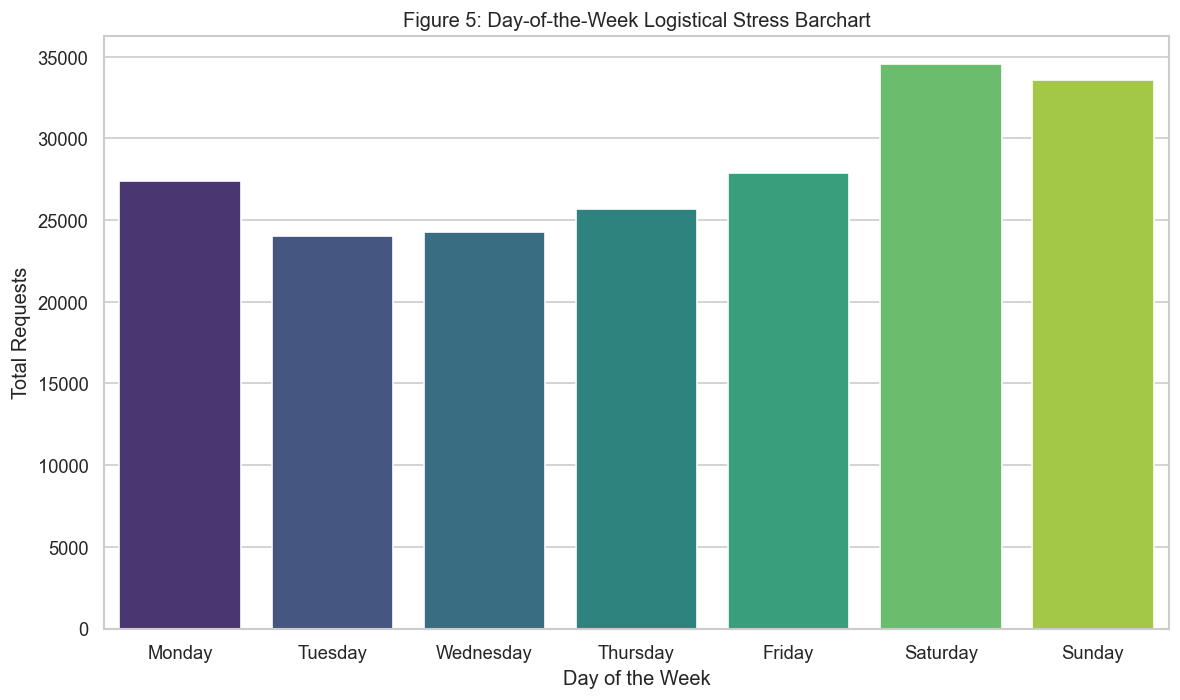

In [22]:
# Figure 5: Day-of-the-Week Logistical Stress Barchart
plt.figure(figsize=(10, 6))
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(x='DayOfWeek', data=df_cleaned, order=order, palette='viridis')
plt.title('Figure 5: Day-of-the-Week Logistical Stress Barchart')
plt.xlabel('Day of the Week')
plt.ylabel('Total Requests')
plt.tight_layout()
plt.show()

## 7. Operational Gap Analysis (Section 5.3)
**Finding:** Pending orders break past driver capacity exactly at **midnight**.
**69.1%** of platform lifecycle = Systemic Gridlock.

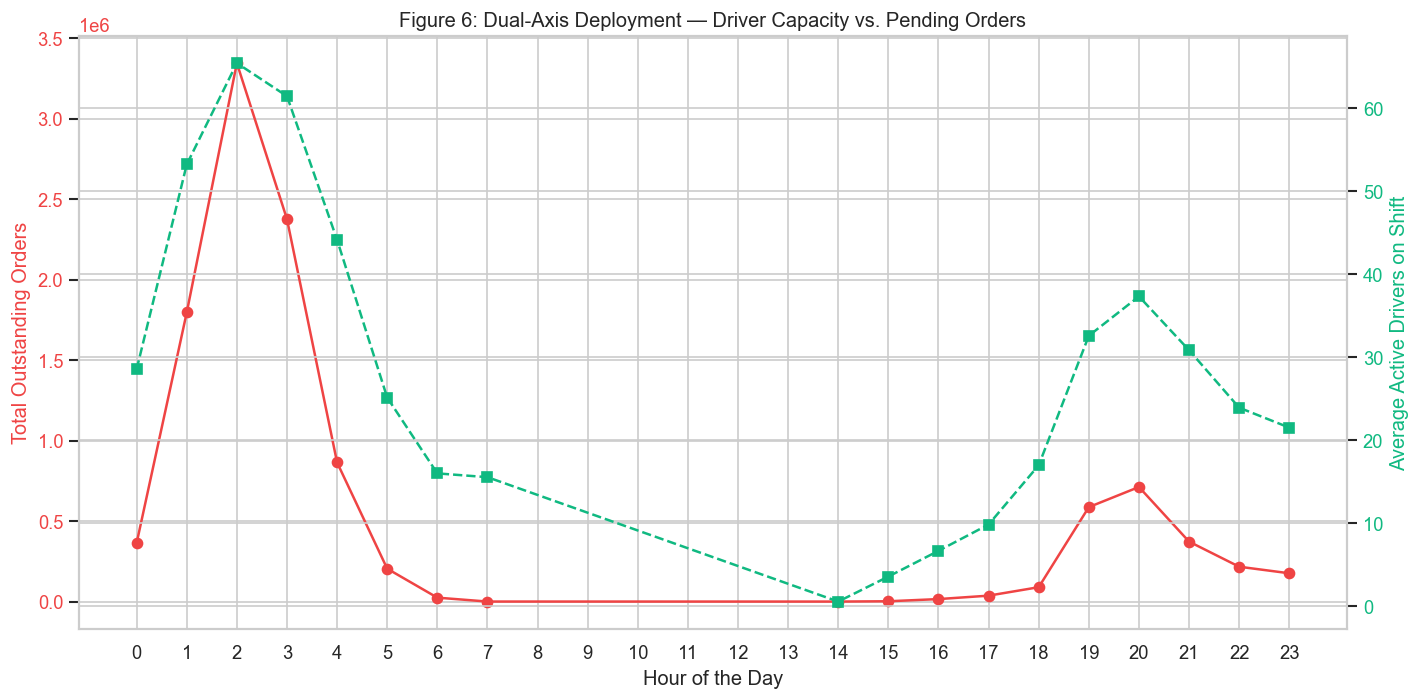

In [23]:
# Figure 6: Dual-Axis — Driver Capacity vs Pending Orders
hourly_metrics = df_cleaned.groupby('Hour').agg(
    total_outstanding_orders=('total_outstanding_orders', 'sum'),
    total_onshift_partners=('total_onshift_partners', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(hourly_metrics['Hour'], hourly_metrics['total_outstanding_orders'],
         marker='o', color='#ef4444', label='Pending Orders Volume')
ax1.set_xlabel('Hour of the Day')
ax1.set_ylabel('Total Outstanding Orders', color='#ef4444')
ax1.tick_params(axis='y', labelcolor='#ef4444')
ax1.set_xticks(range(0, 24))

ax2 = ax1.twinx()
ax2.plot(hourly_metrics['Hour'], hourly_metrics['total_onshift_partners'],
         marker='s', linestyle='--', color='#10b981', label='Avg Active Drivers')
ax2.set_ylabel('Average Active Drivers on Shift', color='#10b981')
ax2.tick_params(axis='y', labelcolor='#10b981')

plt.title('Figure 6: Dual-Axis Deployment — Driver Capacity vs. Pending Orders')
fig.tight_layout()
plt.show()

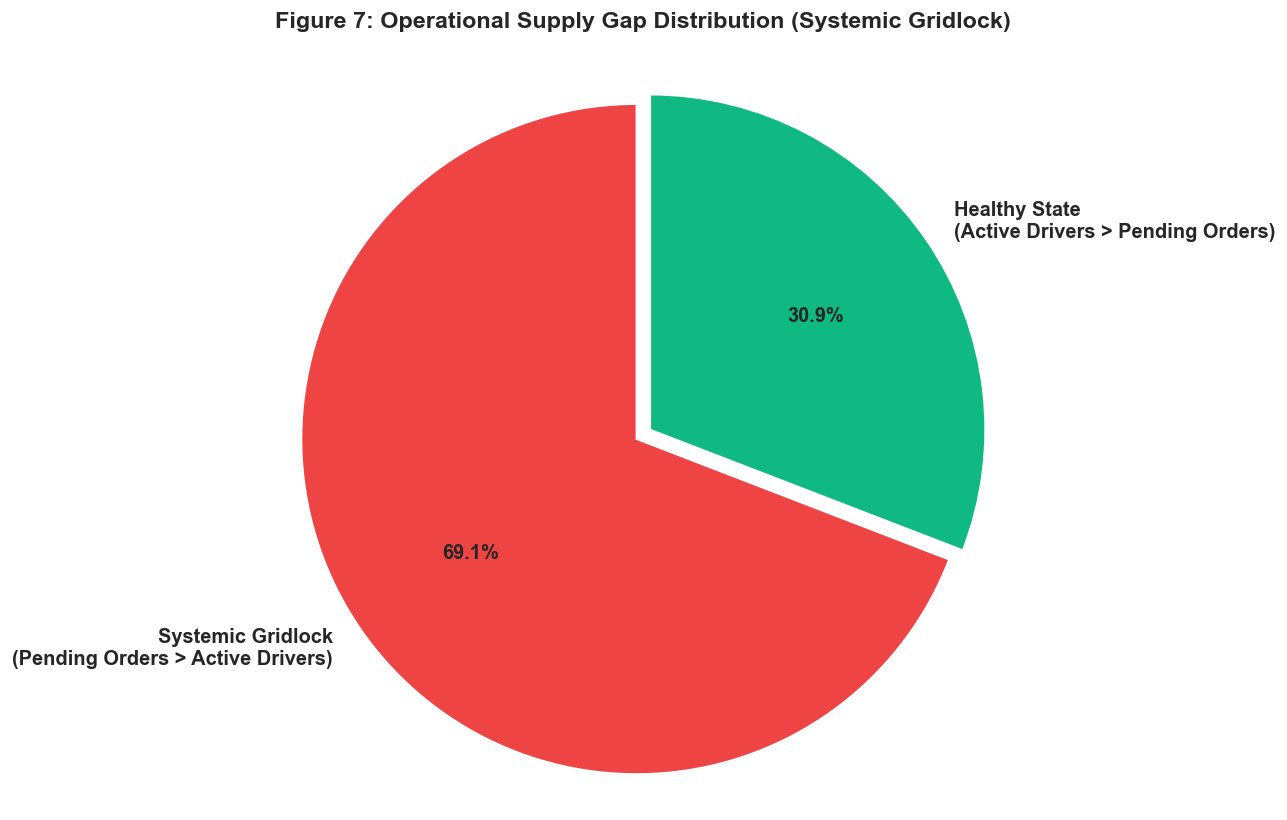

Systemic Gridlock: 69.1% of all operational states


In [24]:
# Figure 7: Operational Supply Gap Distribution (Systemic Gridlock)
df_cleaned['Status'] = np.where(
    df_cleaned['total_outstanding_orders'] > df_cleaned['total_onshift_partners'],
    'Systemic Gridlock\n(Pending Orders > Active Drivers)',
    'Healthy State\n(Active Drivers > Pending Orders)'
)

plt.figure(figsize=(10, 7))
status_counts = df_cleaned['Status'].value_counts()
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90,
        colors=['#ef4444', '#10b981'], explode=(0.05, 0),
        textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title('Figure 7: Operational Supply Gap Distribution (Systemic Gridlock)',
          pad=20, fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

gridlock_key = [k for k in status_counts.index if 'Gridlock' in k][0]
print(f"Systemic Gridlock: {status_counts[gridlock_key]/status_counts.sum()*100:.1f}% of all operational states")

## 8. Predictive ETA Improvement — Gradient Boosting (Section 5.4)
**Why Gradient Boosting?** Natively handles non-linear relationships and multicollinearity — prevents model collapse given the 0.94 supply/demand correlation.
> Report MAE target: **11.62 minutes**

In [25]:
features = ['total_items', 'subtotal', 'total_onshift_partners',
            'total_outstanding_orders', 'supply_deficit_ratio', 'Hour']
X = df_cleaned[features]
y = df_cleaned['delivery_duration_mins']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Gradient Boosting Regressor (XGBoost Logic)...")
model = GradientBoostingRegressor(n_estimators=100, max_depth=6,
                                   learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae  = mean_absolute_error(y_test, predictions)
r2   = r2_score(y_test, predictions)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f} minutes")
print(f"Mean Absolute Error  (MAE)    : {mae:.2f} minutes")
print(f"R² Score                      : {r2:.4f}")

Training Gradient Boosting Regressor (XGBoost Logic)...
Root Mean Squared Error (RMSE): 16.25 minutes
Mean Absolute Error  (MAE)    : 11.62 minutes
R² Score                      : 0.2464


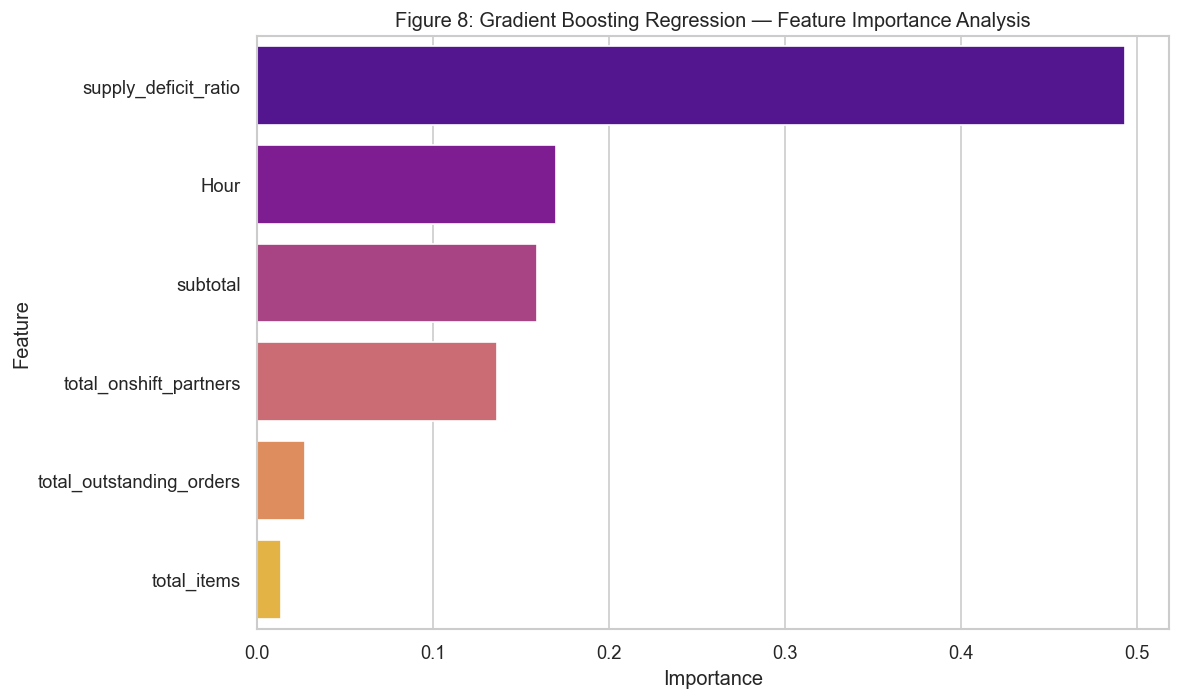


Top feature: supply_deficit_ratio (0.4935)


In [26]:
# Figure 8: Feature Importance Analysis
feature_importances = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='plasma')
plt.title('Figure 8: Gradient Boosting Regression — Feature Importance Analysis')
plt.tight_layout()
plt.show()

print("\nTop feature:", feature_importances.iloc[0]['Feature'],
      f"({feature_importances.iloc[0]['Importance']:.4f})")

## 9. Spatial & Market Demand Analysis (Section 5.5)
**Finding:** Market 1 has *less* order volume yet *higher* median ETA than Market 2 — structural road congestion independent of demand.

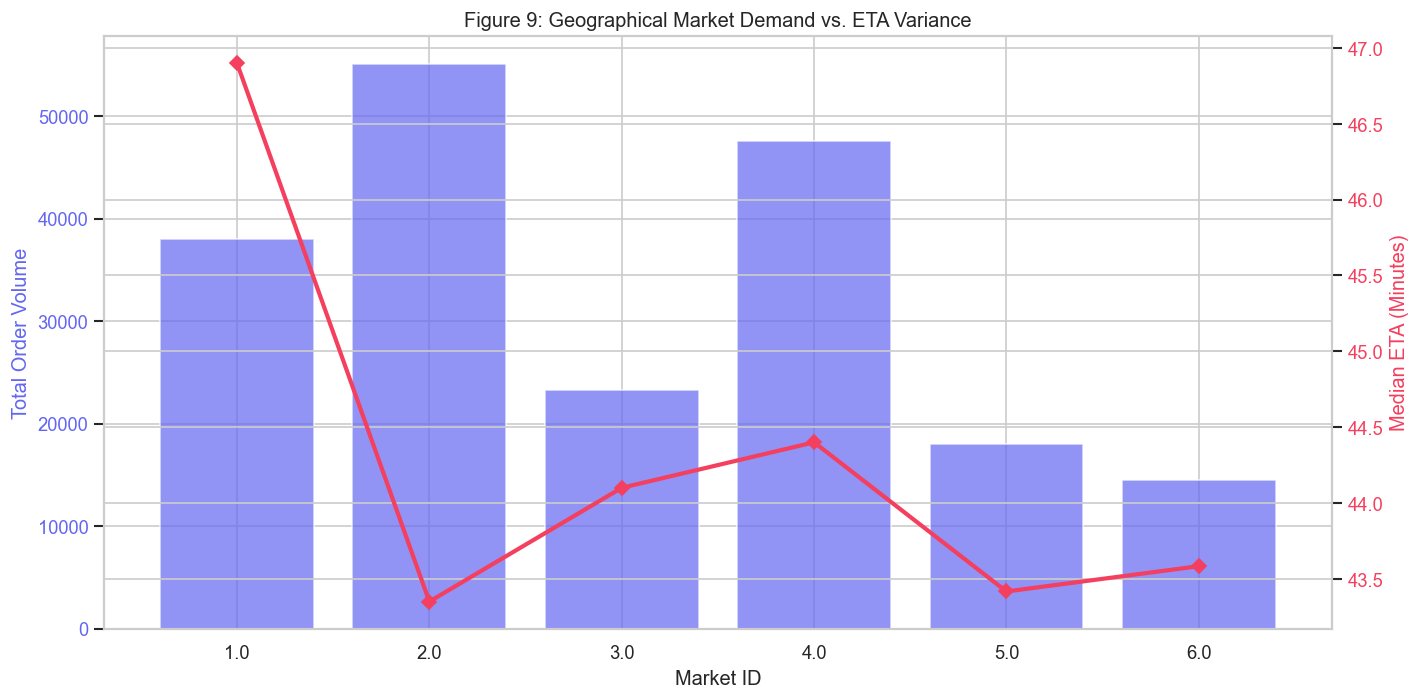

,Market ID,Total Orders,Median ETA (mins)
0,1.0,38017,46.90
1,2.0,55047,43.35
2,3.0,23282,44.10
3,4.0,47589,44.40
4,5.0,17997,43.42
5,6.0,14446,43.58


In [27]:
# Figure 9: Geographical Market Demand vs ETA Variance
market_stats = df_cleaned.groupby('market_id').agg(
    order_count=('delivery_duration_mins', 'count'),
    median_eta=('delivery_duration_mins', 'median')
).reset_index().sort_values('market_id')

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

bars = ax1.bar(market_stats['market_id'].astype(str), market_stats['order_count'],
               color='#6366f1', alpha=0.7, label='Total Orders')
ax1.set_ylabel('Total Order Volume', color='#6366f1')
ax1.tick_params(axis='y', labelcolor='#6366f1')
ax1.set_xlabel('Market ID')

ax2.plot(market_stats['market_id'].astype(str), market_stats['median_eta'],
         marker='D', color='#f43f5e', linewidth=2.5, label='Median ETA (mins)')
ax2.set_ylabel('Median ETA (Minutes)', color='#f43f5e')
ax2.tick_params(axis='y', labelcolor='#f43f5e')

plt.title('Figure 9: Geographical Market Demand vs. ETA Variance')
fig.tight_layout()
plt.show()

display(market_stats.rename(columns={'market_id':'Market ID',
                                      'order_count':'Total Orders',
                                      'median_eta':'Median ETA (mins)'}).round(2))

## 10. Store Category Delay Analysis (Section 5.6)
**Finding:** American, pizza, and Mexican categories dominate order volume and create the most network traffic. Product preparation complexity is a hidden driver of delivery delays.

> Chart: Top 10 store categories ranked by **total order volume** — showing which merchant types concentrate the most demand on the network.

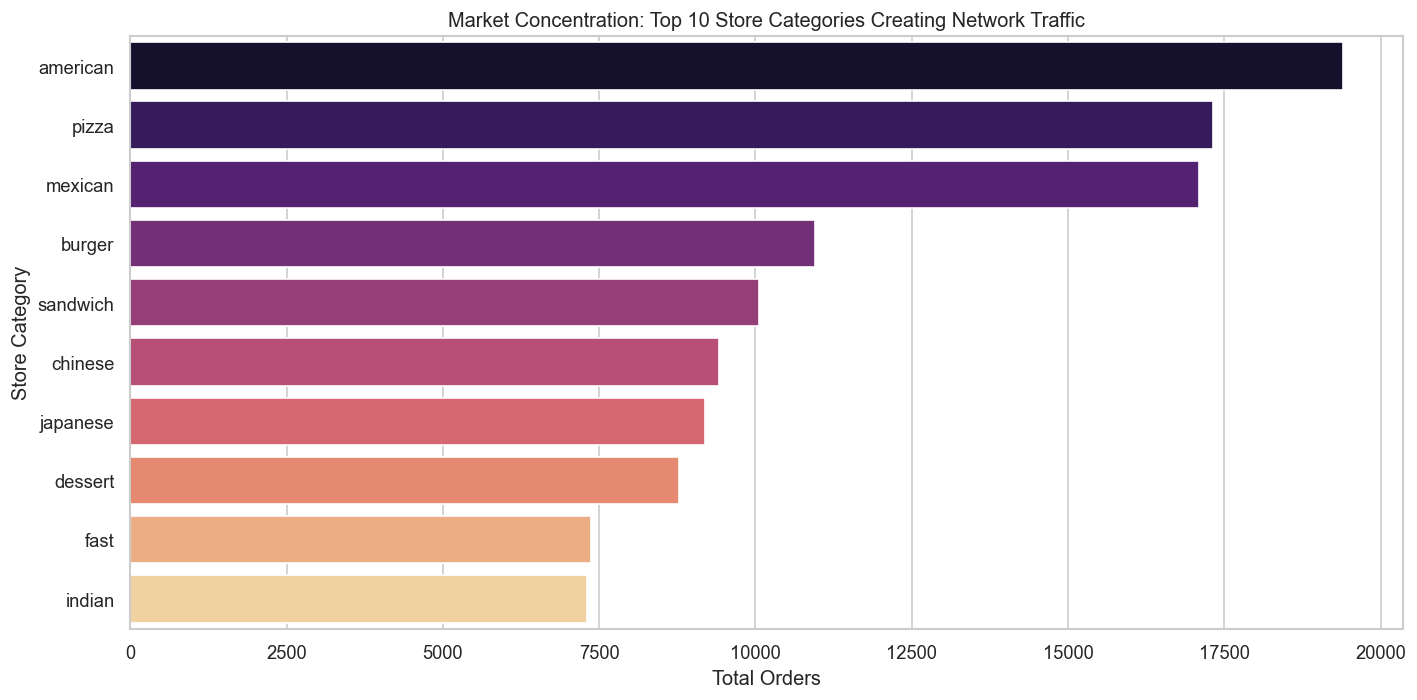

Top category: american with 19394 orders


In [30]:
# Figure 10: Store Category Complexity vs. Delivery Delay Impact
# Top 10 Store Categories by Total Order Volume (Market Concentration)
top_categories = df_cleaned['store_primary_category'].value_counts().nlargest(10)

plt.figure(figsize=(12, 6))
sns.barplot(y=top_categories.index, x=top_categories.values, palette='magma')
plt.title('Market Concentration: Top 10 Store Categories Creating Network Traffic')
plt.xlabel('Total Orders')
plt.ylabel('Store Category')
plt.tight_layout()
plt.show()

print("Top category:", top_categories.index[0], "with", top_categories.values[0], "orders")

## 11. Summary & Recommendations (Section 6)

### Findings Summary
| Finding | Metric |
|---------|--------|
| Systemic Gridlock frequency | **69.1%** of operational states |
| Peak demand window | **01:00 AM – 03:00 AM** |
| Max pending orders vs max drivers | **285 vs 171** (114-unit deficit) |
| ML Model MAE | **11.62 minutes** |
| Highest-value B2B tail delay | Up to **297.7 minutes** |

### Recommendations

| # | Problem Statement | Recommendation | KPI Target |
|---|-------------------|----------------|------------|
| 1 | Time-based demand variance | Deploy automated ratio-based **surge pricing** at 01:00 AM (Q3) | Reduce cancellations **−15%**, off-peak revenue **+8.5%** |
| 2 | Real-time supply deficits | Integrate **11.62-min MAE ML-ETA model** into merchant app (6 months) | Reduce disputes **−20%**, merchant retention **+12%** |
| 3 | ETA precision via order complexity | Implement **Complexity-Priority Queue** for 95th-pct B2B orders (90 days) | Eliminate 150-min tail delays, enterprise revenue **+10%** |